# ML Project

## Data Modeling

### Ranking Problem (First Problem)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

# Load the dataset
file_path = '../dataset_for_modeling/features_for_ranking.csv'
rank_teams = pd.read_csv(file_path)

feature_columns = [
    "player_awards", "net_rating", "off_eff", "def_eff", "home_win_pct",
    "away_win_pct", "reb_dif", "conf_win_pct", "ast_dif", "blk_dif",
    "pf_dif", "coach_awards", "efg_pct", "win_pct", "pts_per_poss",
    "ts_pct", "eff_x_pace", "net_four_factors", "pyth_wins"
]

# Add 'rank' and 'confID' for lagging and grouping
base_columns = feature_columns + ['rank', 'confID']

# Ensure data is sorted by team and year for correct lagging
rank_teams = rank_teams.sort_values(by=['tmID', 'year'])


In [2]:
# Create Lag-1 Features (Last Year's Stats)
lag1_feature_names = [f"{col}_lag1" for col in base_columns]
rank_teams[lag1_feature_names] = rank_teams.groupby('tmID')[base_columns].shift(1)

# Create 3-Year Rolling Avg Features
cols_to_weight = feature_columns + ['rank']
avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in cols_to_weight]

# Define the weighted average function
def weighted_avg(series):
    """
    Calculates a weighted average adapting to available history (1, 2, or 3 years).
    Weights: 0.5 (Last Year), 0.3 (2 Years Ago), 0.2 (3 Years Ago).
    """
    weights = np.array([0.2, 0.3, 0.5])
    
    # Convert series to array to handle NaNs safely
    s = np.array(series)
    mask = ~np.isnan(s)
    
    # If no valid data exists in the window, return NaN
    if not np.any(mask):
        return np.nan
        
    # Adjust weights to the window size and available data
    w = weights[-len(s):]
    valid_s = s[mask]
    valid_w = w[mask]
    
    # Normalize by the sum of valid weights
    return np.sum(valid_s * valid_w) / np.sum(valid_w)

# Calculate rolling average on the lag-1 features
# min_periods=1 ensures we calculate averages even for teams with short history
rolling_avg_features = rank_teams.groupby('tmID')[[f"{col}_lag1" for col in cols_to_weight]] \
                                 .rolling(window=3, min_periods=1) \
                                 .apply(weighted_avg, raw=True)

# Align the rolling average index
rank_teams[avg3yr_feature_names] = rolling_avg_features.reset_index(level=0, drop=True)

# Clean Data
# Only drop rows if Lag-1 data is missing.
# This keeps teams that have Year N-1 data but lack Year N-2 or N-3.
model_df = rank_teams.dropna(subset=lag1_feature_names)

print(f"Original shape: {rank_teams.shape}, Model-ready shape: {model_df.shape}")


Original shape: (142, 65), Model-ready shape: (122, 65)


In [3]:
# The target is always the rank of the CURRENT year
target_col = 'rank'

# Experiment A: Use only last year's stats
features_lag1 = [f"{col}_lag1" for col in feature_columns] + ['rank_lag1']

# Experiment B: Use only the 3-year average stats
features_avg3yr = [f"{col}_avg3yr_lag" for col in feature_columns] + ['rank_avg3yr_lag']

# Experiment C: Use both sets
features_combined = features_lag1 + features_avg3yr

feature_sets = {
    "Lag 1 Only": features_lag1,
    "Avg 3-Year Only": features_avg3yr,
    "Combined": features_combined
}


In [4]:
TEST_YEAR = 10
VALIDATION_YEAR = 9

# Train: All years BEFORE the validation year
train_df = model_df[model_df['year'] < VALIDATION_YEAR] # Years 2-8
y_train = train_df[target_col]

# Validate: Only the validation year
val_df = model_df[model_df['year'] == VALIDATION_YEAR] # Year 9
y_val = val_df[target_col]

# Test: Only the test year
test_df = model_df[model_df['year'] == TEST_YEAR] # Year 10
y_test = test_df[target_col]

print(f"Training observations: {len(train_df)}")
print(f"Validation observations: {len(val_df)}")
print(f"Test observations: {len(test_df)}")


Training observations: 96
Validation observations: 13
Test observations: 13


In [5]:
# Get the baseline prediction (last year's rank)
y_pred_baseline = val_df['rank_lag1']

y_pred_baseline.head()

# Evaluate baseline on the Validation set
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
spearman_baseline, _ = spearmanr(y_val, y_pred_baseline)

print("--- Baseline Model (on Validation Set) ---")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  Spearman Rank: {spearman_baseline:.4f}")


--- Baseline Model (on Validation Set) ---
  MAE: 1.5385
  Spearman Rank: 0.4008


In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'SVR':SVR(),
    'AdaBoost':AdaBoostRegressor(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    # Define X data based on the current feature set
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    for name, model in models.items():
        # Fit model
        model.fit(X_train_scaled, y_train)
        y_pred_val = model.predict(X_val_scaled)
        
        # Evaluate model
        mae = mean_absolute_error(y_val, y_pred_val)
        spearman_corr, _ = spearmanr(y_val, y_pred_val)
        
        print(f"  Model: {name}")
        print(f"    MAE: {mae:.4f} (Baseline: {mae_baseline:.4f})")
        print(f"    Spearman: {spearman_corr:.4f} (Baseline: {spearman_baseline:.4f})")
        
        results.append((fs_name, name, mae, spearman_corr))

best_result = min(results, key=lambda item: item[2])
best_fs_name, best_model_name, best_mae, best_spearman = best_result

print(f"\n--- Best Model from Validation (based on MAE) ---")
print(f"  Feature Set: {best_fs_name}")
print(f"  Model: {best_model_name}")
print(f"  Spearman: {best_spearman:.4f}")



--- Testing Feature Set: Lag 1 Only ---
  Model: Linear Regression
    MAE: 2.0144 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.6900 (Baseline: 1.5385)
    Spearman: 0.1551 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.9915 (Baseline: 1.5385)
    Spearman: 0.1108 (Baseline: 0.4008)
  Model: Ridge Regression
    MAE: 1.9424 (Baseline: 1.5385)
    Spearman: 0.0416 (Baseline: 0.4008)
  Model: SVR
    MAE: 1.6298 (Baseline: 1.5385)
    Spearman: 0.2299 (Baseline: 0.4008)
  Model: AdaBoost
    MAE: 1.8926 (Baseline: 1.5385)
    Spearman: 0.0360 (Baseline: 0.4008)

--- Testing Feature Set: Avg 3-Year Only ---
  Model: Linear Regression
    MAE: 1.7001 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.7492 (Baseline: 1.5385)
    Spearman: -0.0526 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.7169 (Baseline: 1.5385)
    Spearman: 0.0693 (Baseline: 0.4008)
  Model: Ridge Regression


In [7]:
# Prepare Data (Train + Validation combined for Cross-Validation)
# We use the best feature set found in the previous step
best_features = feature_sets[best_fs_name]

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

# Define Models and their Hyperparameter Grids
model_configs = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 300, 500, 1000],
            "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "model__C": [0.1, 1, 10, 100, 1000],
            "model__kernel": ['linear', 'rbf', 'poly'],
            "model__epsilon": [0.01, 0.1, 0.2, 0.5],
            "model__gamma": ['scale', 'auto', 0.1, 0.01]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100, 300, 500],
            "model__learning_rate": [0.001, 0.01, 0.1, 1.0],
            "model__loss": ['linear', 'square', 'exponential']
        }
    },
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {
            "model__fit_intercept": [True, False]
        }
    }
}

# Run Systematic Grid Search for all Models
results = []
best_overall_model = None
best_overall_score = -float("inf") # Since we use neg_MAE, closer to 0 is better

print(f"--- Starting Extensive Grid Search on {len(model_configs)} Models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")
    
    # Create a Pipeline: Scaler -> Model
    # Scaling is crucial for SVR/Ridge, and harmless for Trees
    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', config['model'])
    ])
    
    # Setup Grid Search
    grid = GridSearchCV(
        pipeline, 
        config['params'], 
        cv=3, # 3-Fold Cross Validation
        scoring='neg_mean_absolute_error', 
        n_jobs=-1,
        verbose=1
    )
    
    # Train
    grid.fit(X_train_full, y_train_full)
    
    # Get results (Convert neg_MAE to positive MAE for readability)
    best_mae = -grid.best_score_
    
    print(f"  > Best MAE: {best_mae:.4f}")
    print(f"  > Best Params: {grid.best_params_}")
    
    results.append({
        "Model": name,
        "MAE": best_mae,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })
    
    # Track the global winner
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = grid.best_estimator_
        best_model_name = name

# Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MAE', ascending=True)

print("\n--- Model Classification Table ---")
print(results_df[['Model', 'MAE', 'Best_Params']].to_string(index=False))

print("\n==================================================")
print(f"Best Model in Training: {best_model_name} with MAE: {-best_overall_score:.4f}")
print("==================================================")

# Set final_model to the winner
final_model = best_overall_model


--- Starting Extensive Grid Search on 6 Models ---

Training Random Forest...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits


  > Best MAE: 1.6160
  > Best Params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500}

Training Gradient Boosting...
Fitting 3 folds for each of 192 candidates, totalling 576 fits
  > Best MAE: 1.6626
  > Best Params: {'model__learning_rate': 0.005, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.9}

Training Ridge Regression...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
  > Best MAE: 1.5425
  > Best Params: {'model__alpha': 50.0}

Training SVR...
Fitting 3 folds for each of 240 candidates, totalling 720 fits
  > Best MAE: 1.5123
  > Best Params: {'model__C': 0.1, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Training AdaBoost...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
  > Best MAE: 1.6368
  > Best Params: {'model__learning_rate': 0.1, 'model__loss': 'linear', 'model__n_estimators': 50}

Training L


--- Baseline Model Evaluation (on Test Set: Year 10) ---
  MAE: 2.4615
  Spearman Rank: -0.1299


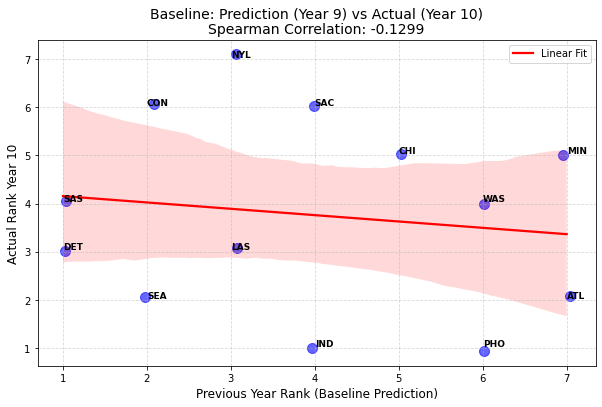

In [8]:
# --- Baseline for the final test set
y_pred_baseline_test = test_df['rank_lag1']
mae_baseline_test = mean_absolute_error(y_test, y_pred_baseline_test)
spearman_baseline_test, _ = spearmanr(y_test, y_pred_baseline_test)

print("\n--- Baseline Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_baseline_test:.4f}")
print(f"  Spearman Rank: {spearman_baseline_test:.4f}")

plt.figure(figsize=(10, 6))

# Create Plot (Scatter + Regression Line)
# x_jitter helps to see overlapping points (e.g., two teams that were rank 1)
sns.regplot(x='rank_lag1', y='rank', data=test_df, 
            x_jitter=0.1, y_jitter=0.1, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'label': 'Linear Fit'})

# Add Labels (Team Name) to each point
for i, row in test_df.iterrows():
    plt.text(row['rank_lag1'], row['rank'], row['tmID'], 
             fontsize=9, ha='left', va='bottom', fontweight='bold')

plt.title(f"Baseline: Prediction (Year 9) vs Actual (Year 10)\nSpearman Correlation: {spearman_baseline_test:.4f}", fontsize=14)
plt.xlabel("Previous Year Rank (Baseline Prediction)", fontsize=12)
plt.ylabel("Actual Rank Year 10", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


--- Evaluating all optimized models on the Test Set (Year 10) ---

--- Final Showdown: Validation vs Test Performance ---
            Model  Validation MAE  Test MAE (Year 10)  Test RMSE (Year 10)  Test Spearman  Generalization Gap
Gradient Boosting        1.662585            1.565960             1.949131       0.340732           -0.096625
    Random Forest        1.616001            1.621726             2.013023       0.204993            0.005726
         AdaBoost        1.636795            1.667556             2.014118       0.193913            0.030761
 Ridge Regression        1.542538            1.692867             2.178466       0.152360            0.150329
              SVR        1.512323            1.875235             2.450020       0.088646            0.362911
Linear Regression        2.176105            2.362403             3.035991       0.049863            0.186298


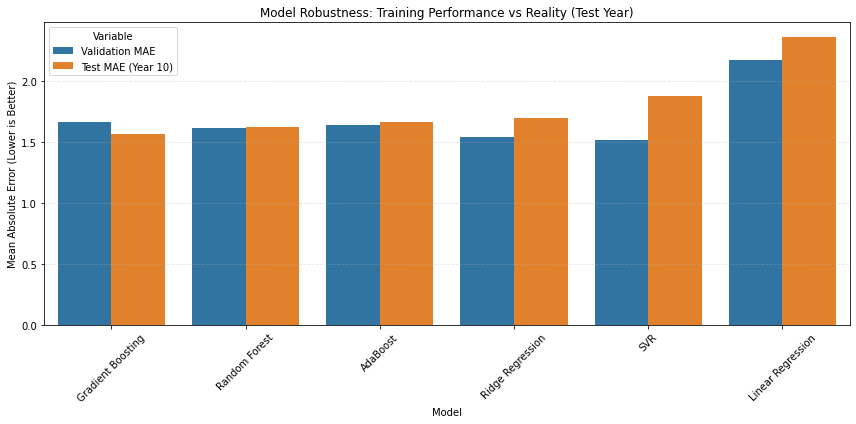


Best Model in Testing (Year 10): Gradient Boosting


In [9]:
# Prepare Test Data
X_test = test_df[best_features]
y_test = test_df[target_col]

print(f"--- Evaluating all optimized models on the Test Set (Year 10) ---")

final_comparison = []

# Iterate through the results of the Grid Search
for index, row in results_df.iterrows():
    model_name = row['Model']
    trained_model = row['Best_Estimator']
    val_mae = row['MAE']
    
    # Predict on Test Set (Year 10)
    y_pred_test = trained_model.predict(X_test)
    
    # Calculate Test Metrics
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_spearman, _ = spearmanr(y_test, y_pred_test)
    
    final_comparison.append({
        "Model": model_name,
        "Validation MAE": val_mae,
        "Test MAE (Year 10)": test_mae,
        "Test RMSE (Year 10)": test_rmse,
        "Test Spearman": test_spearman,
        "Generalization Gap": test_mae - val_mae,
        "Best_Estimator": trained_model
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(final_comparison)
comparison_df = comparison_df.sort_values(by='Test MAE (Year 10)', ascending=True)

display_cols = ["Model", "Validation MAE", "Test MAE (Year 10)", "Test RMSE (Year 10)", "Test Spearman", "Generalization Gap"]

print("\n--- Final Showdown: Validation vs Test Performance ---")
print(comparison_df[display_cols].to_string(index=False))

# Plot Comparison
plt.figure(figsize=(12, 6))
tidy = comparison_df.melt(id_vars='Model').rename(columns=str.title)
tidy = tidy[tidy['Variable'].isin(['Validation MAE', 'Test MAE (Year 10)'])]

sns.barplot(x='Model', y='Value', hue='Variable', data=tidy)
plt.title("Model Robustness: Training Performance vs Reality (Test Year)")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

best_test_model_row = comparison_df.iloc[0]
final_model_name = best_test_model_row['Model']
final_model = best_test_model_row['Best_Estimator']
mae_final = best_test_model_row['Test MAE (Year 10)']

print(f"\nBest Model in Testing (Year 10): {best_test_model_row['Model']}")


In [10]:
# Generate Final Predictions with the Best Model
y_pred_final = final_model.predict(X_test)

# Create the final results DataFrame
final_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
final_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
final_results_df['predicted_rank_raw'] = y_pred_final

# Rank the model's raw predictions to get a 1-N ranking
final_results_df['predicted_rank_model'] = final_results_df.groupby('confID')['predicted_rank_raw'] \
                                                          .rank(method='first', ascending=True) \
                                                          .astype(int)

# Sort for easy viewing
final_results_df = final_results_df.sort_values(by=['confID', 'actual_rank'])

print("\n--- Final Predicted vs. Actual Rankings (Year 10) ---")
print(final_results_df[['confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model']].to_string(index=False))

improvement_pct = ((mae_baseline_test - mae_final) / mae_baseline_test) * 100

print(f"\n--- Performance Comparison ---")
print(f"Baseline Error (Previous Year Rank): {mae_baseline_test:.4f}")
print(f"Model Error (With Custom Features): {mae_final:.4f}")
print(f"--------------------------------------------------")
print(f"TOTAL IMPROVEMENT: {improvement_pct:.2f}%")



--- Final Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     1
    EA  ATL            2            7.0                     7
    EA  DET            3            1.0                     2
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     5
    EA  CON            6            2.0                     3
    EA  NYL            7            3.0                     4
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     1
    WE  LAS            3            3.0                     2
    WE  SAS            4            1.0                     5
    WE  MIN            5            7.0                     6
    WE  SAC            6            4.0                     4

--- Performance Comparison ---
Baseline Error (Previous Year Rank): 2.4615
M

In [11]:
# Function to calculate NDCG
def calculate_ndcg(df):
    ndcg_values = []
    
    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf].copy()
        
        # Transform Rank into Relevance (Rank 1 = High Relevance)
        # Example: If 6 teams, Rank 1 gets score 6, Rank 6 gets score 1
        max_rank = conf_data['actual_rank'].max()
        
        # Create relevance arrays (1 sample, N items)
        true_relevance = [((max_rank + 1) - conf_data['actual_rank'].values)]
        predicted_scores = [((max_rank + 1) - conf_data['predicted_rank_model'].values)]
        
        # Calculate NDCG
        score = ndcg_score(true_relevance, predicted_scores)
        ndcg_values.append(score)
        
    return np.mean(ndcg_values)

# Calculate and Print
avg_ndcg = calculate_ndcg(final_results_df)
print(f"NDCG Score: {avg_ndcg:.4f} (Closer to 1.0 is better)")


NDCG Score: 0.9421 (Closer to 1.0 is better)


In [12]:
def calculate_business_metrics(df):
    precisions = []
    
    print(f"\n--- Business Metrics Analysis (Playoff Precision) ---")

    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf]
        
        # --- Precision@4 (Playoff Accuracy) ---
        # Identify the actual teams that made Top 4
        actual_playoff_teams = set(conf_data[conf_data['actual_rank'] <= 4]['tmID'])
        
        # Identify the teams the MODEL predicted for Top 4
        predicted_playoff_teams = set(conf_data[conf_data['predicted_rank_model'] <= 4]['tmID'])
        
        # How many did we get right?
        correct_hits = len(actual_playoff_teams.intersection(predicted_playoff_teams))
        precision = correct_hits / 4.0 # Since 4 teams qualify
        precisions.append(precision)
        
        print(f"Conference {conf}: Playoff Precision = {precision*100:.0f}% ({correct_hits}/4)")
        
    avg_precision = np.mean(precisions)
    
    print(f"---------------------------------")
    print(f"AVG Playoff Precision: {avg_precision*100:.1f}%")

# Run the function
calculate_business_metrics(final_results_df)



--- Business Metrics Analysis (Playoff Precision) ---
Conference EA: Playoff Precision = 50% (2/4)
Conference WE: Playoff Precision = 75% (3/4)
---------------------------------
AVG Playoff Precision: 62.5%


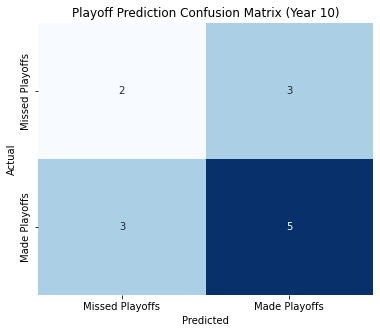

In [13]:
# Create Binary Columns for Playoffs (Top 4 = Yes, >4 = No)
final_results_df['Actual_Playoff'] = final_results_df['actual_rank'] <= 4
final_results_df['Predicted_Playoff'] = final_results_df['predicted_rank_model'] <= 4

# Generate Confusion Matrix
cm = confusion_matrix(final_results_df['Actual_Playoff'], final_results_df['Predicted_Playoff'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Missed Playoffs', 'Made Playoffs'],
            yticklabels=['Missed Playoffs', 'Made Playoffs'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Playoff Prediction Confusion Matrix (Year 10)')
plt.show()



=== Built-in feature importances (final model) ===
                feature  importance
  net_rating_avg3yr_lag    0.177820
           reb_dif_lag1    0.081242
     win_pct_avg3yr_lag    0.067429
        net_rating_lag1    0.059820
away_win_pct_avg3yr_lag    0.037875
        eff_x_pace_lag1    0.037577
     def_eff_avg3yr_lag    0.037468
           def_eff_lag1    0.037045
      away_win_pct_lag1    0.033424
pts_per_poss_avg3yr_lag    0.033211
     ast_dif_avg3yr_lag    0.031668
     blk_dif_avg3yr_lag    0.029680
           blk_dif_lag1    0.027860
  eff_x_pace_avg3yr_lag    0.022104
   pyth_wins_avg3yr_lag    0.020711


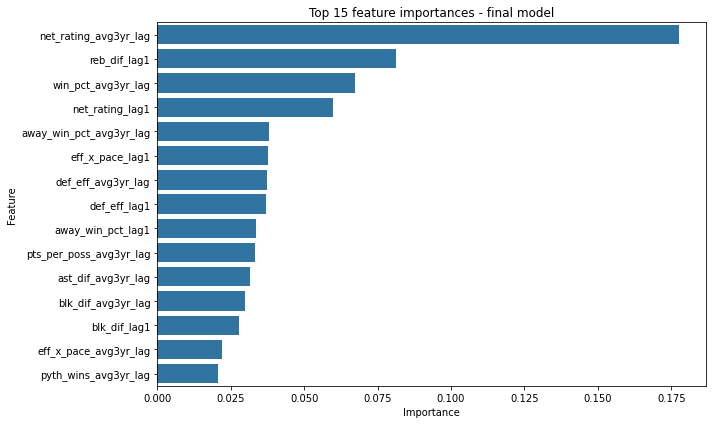

In [19]:
# === Feature importance for final model ===
from sklearn.inspection import permutation_importance

X_test = test_df[best_features]
y_test = test_df[target_col]

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = X_test.columns

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\n=== Built-in feature importances (final model) ===")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="importance",
        y="feature",
        data=fi_df.head(15),
        orient="h"
    )
    plt.title("Top 15 feature importances - final model")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    result = permutation_importance(
        final_model,
        X_test,
        y_test,
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
        scoring="neg_mean_absolute_error"
    )

    feature_names = X_test.columns
    perm_df = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    print("\n=== Permutation feature importances (final model) ===")
    print(perm_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="importance",
        y="feature",
        data=perm_df.head(15),
        orient="h"
    )
    plt.title("Top 15 permutation importances - final model")
    plt.xlabel("Importance (MAE drop when shuffled)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



=== White-box Ridge model (interpretation only) ===
Test MAE: 2.1971
Test Spearman: -0.0055

Top 15 coefficients by absolute value:
efg_pct_lag1             1.265860
pts_per_poss_lag1       -1.115170
rank_avg3yr_lag          1.096888
rank_lag1               -0.961577
efg_pct_avg3yr_lag      -0.951213
net_rating_avg3yr_lag    0.940926
off_eff_avg3yr_lag       0.756818
pyth_wins_lag1          -0.739599
def_eff_lag1            -0.725791
net_four_factors_lag1    0.680120
pf_dif_lag1              0.597519
ast_dif_avg3yr_lag      -0.582378
win_pct_lag1            -0.565246
home_win_pct_lag1       -0.556863
def_eff_avg3yr_lag       0.536977
dtype: float64


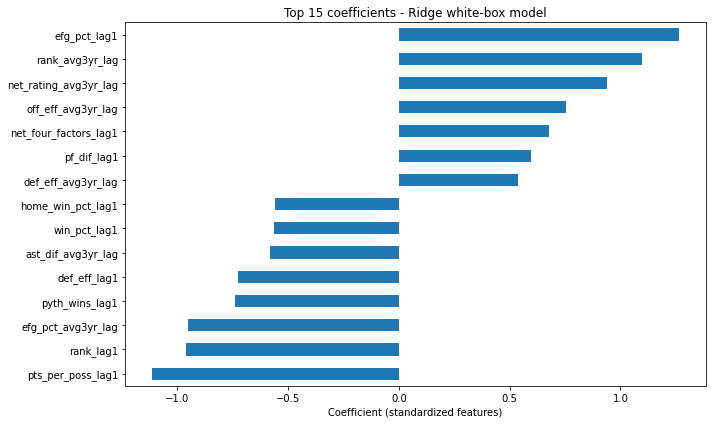

In [20]:
# === White-box Ridge model for interpretation ===
from sklearn.linear_model import Ridge

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

scaler_wb = StandardScaler()
X_train_full_scaled = scaler_wb.fit_transform(X_train_full)
X_test_scaled = scaler_wb.transform(X_test)

ridge_wb = Ridge(alpha=1.0)
ridge_wb.fit(X_train_full_scaled, y_train_full)

y_pred_ridge = ridge_wb.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
spearman_ridge, _ = spearmanr(y_test, y_pred_ridge)

print("\n=== White-box Ridge model (interpretation only) ===")
print(f"Test MAE: {mae_ridge:.4f}")
print(f"Test Spearman: {spearman_ridge:.4f}")

coef_series = pd.Series(
    ridge_wb.coef_,
    index=X_train_full.columns
).sort_values(key=abs, ascending=False)

print("\nTop 15 coefficients by absolute value:")
print(coef_series.head(15))

plt.figure(figsize=(10, 6))
coef_series.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 coefficients - Ridge white-box model")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()


### Player Awards Problem (Third Problem)

#### Most Improved Player Award

##### Data Analyses

/tmp/ipykernel_7583/3478013054.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

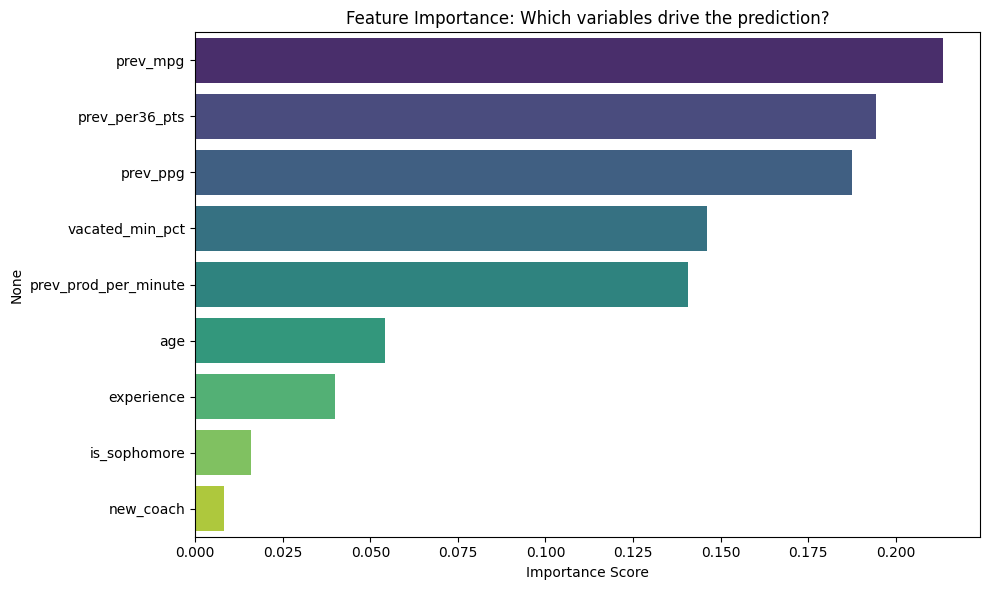

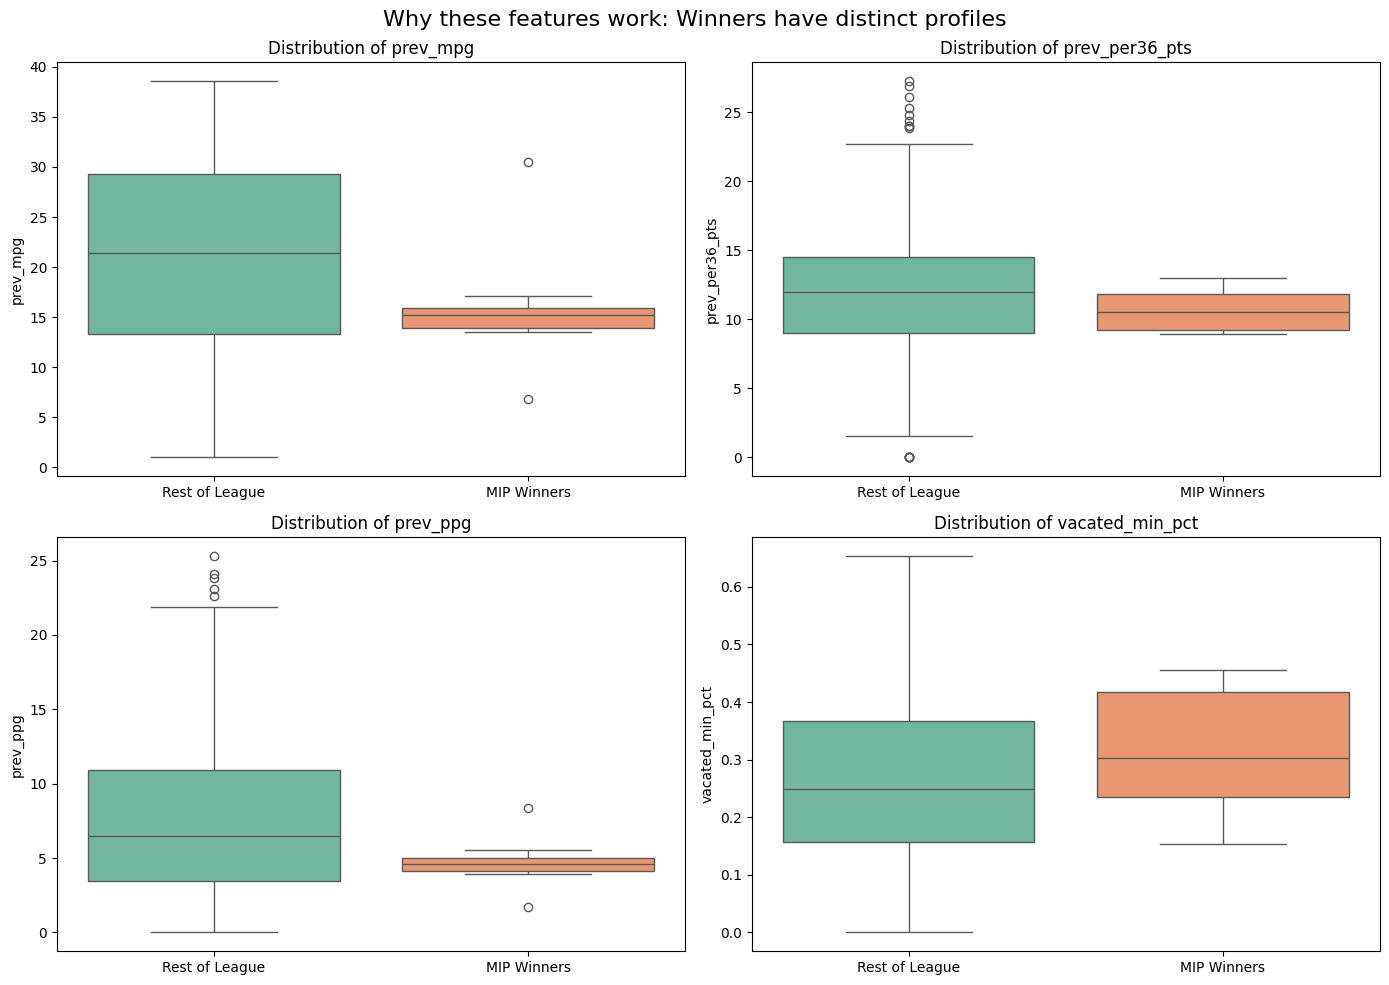

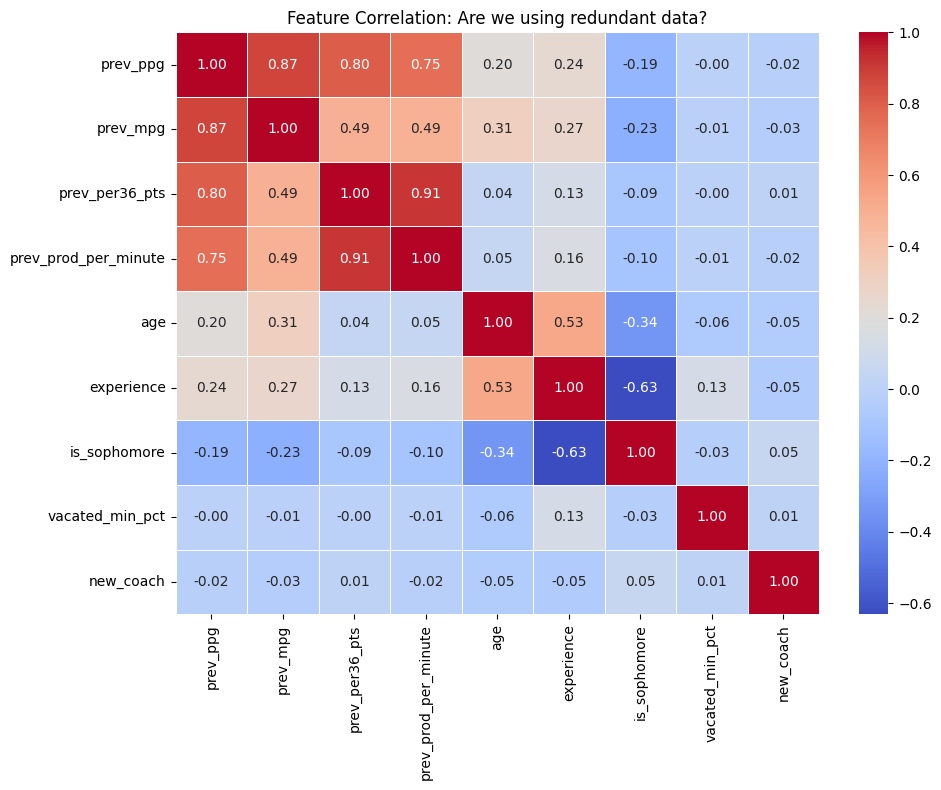

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')

# --- Feature Engineering ---

# Demographics
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_players_teams = pd.merge(df_players_teams, df_players[['bioID', 'birth_year']], left_on='playerID', right_on='bioID', how='left')
df_players_teams.sort_values(['playerID', 'year'], inplace=True)
df_players_teams['experience'] = df_players_teams.groupby('playerID').cumcount()
df_players_teams['is_sophomore'] = (df_players_teams['experience'] == 1).astype(int)
df_players_teams['age'] = (1996 + df_players_teams['year']) - df_players_teams['birth_year']
df_players_teams['age'] = df_players_teams['age'].fillna(25)

# Team Context (Vacated Minutes)
rosters = df_players_teams.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_list = []
years = sorted(df_players_teams['year'].unique())
teams = df_players_teams['tmID'].unique()

for yr in years:
    if yr == 1: continue
    prev = yr - 1
    for tm in teams:
        ros_prev = rosters[(rosters['year'] == prev) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty: 
            vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': 0})
            continue
        
        left = set(ros_prev['playerID']) - set(ros_curr['playerID'])
        vacated = ros_prev[ros_prev['playerID'].isin(left)]['minutes'].sum()
        total = ros_prev['minutes'].sum()
        ratio = vacated / total if total > 0 else 0
        vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': ratio})

df_vacated = pd.DataFrame(vacated_list)

# Aggregation
stats = df_players_teams.groupby(['playerID', 'year']).agg({
    'GP': 'sum', 'minutes': 'sum', 'points': 'sum', 'rebounds': 'sum', 'assists': 'sum',
    'tmID': 'first', 'experience': 'first', 'is_sophomore': 'max', 'age': 'max'
}).reset_index()

# Basic & Advanced Stats
stats['ppg'] = stats['points'] / stats['GP']
stats['mpg'] = stats['minutes'] / stats['GP']
# Per 36 Minutes
stats['per36_pts'] = (stats['points'] / stats['minutes'].replace(0, 1)) * 36
# Production Per Minute
stats['prod_per_minute'] = (stats['points'] + stats['rebounds'] + stats['assists']) / stats['minutes'].replace(0, 1)

# Build Dataset (Lagged Features)
data_rows = []
for yr in years:
    if yr == 1: continue
    curr = stats[stats['year'] == yr][['playerID', 'year', 'tmID', 'age', 'experience', 'is_sophomore']].copy()
    prev = stats[stats['year'] == yr - 1].copy()
    prev.columns = [f'prev_{c}' if c != 'playerID' else 'playerID' for c in prev.columns]
    merged = pd.merge(curr, prev, on='playerID', how='inner')
    data_rows.append(merged)

df_final = pd.concat(data_rows, ignore_index=True)
df_final = pd.merge(df_final, df_vacated, on=['year', 'tmID'], how='left')

# Coaching Change
coaches = df_coaches[['year', 'tmID', 'coachID']].drop_duplicates(subset=['year', 'tmID'])
df_final = pd.merge(df_final, coaches, on=['year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'curr_coach'}, inplace=True)
coaches_prev = coaches.copy()
coaches_prev['next_year'] = coaches_prev['year'] + 1
df_final = pd.merge(df_final, coaches_prev[['next_year', 'tmID', 'coachID']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'prev_coach'}, inplace=True)
df_final['new_coach'] = (df_final['curr_coach'] != df_final['prev_coach']).astype(int)

# Target
mip_winners = df_awards[df_awards['award'] == 'Most Improved Player']
winners_map = mip_winners[['playerID', 'year']].copy()
winners_map['won'] = 1
df_final = pd.merge(df_final, winners_map, on=['playerID', 'year'], how='left')
df_final['won'] = df_final['won'].fillna(0).astype(int)

features = [
    'prev_ppg', 'prev_mpg', 
    'prev_per36_pts', 'prev_prod_per_minute',
    'age', 'experience', 'is_sophomore',     
    'vacated_min_pct', 'new_coach'
]
df_final[features] = df_final[features].fillna(0)

# 1. Feature Importance (Model Based)
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(df_final[features], df_final['won'])

plt.figure(figsize=(10, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Feature Importance: Which variables drive the prediction?')
plt.xlabel('Importance Score')
plt.tight_layout()

# 2. Winners vs Non-Winners Distribution (Boxplots)
# Select top 4 features for detailed view
top_features = imp.index[:4].tolist()
df_plot = df_final.copy()
df_plot['Status'] = df_plot['won'].map({0: 'Rest of League', 1: 'MIP Winners'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('')

plt.suptitle('Why these features work: Winners have distinct profiles', fontsize=16)
plt.tight_layout()

# 3. Correlation Heatmap (Redundancy Check)
plt.figure(figsize=(10, 8))
corr = df_final[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation: Are we using redundant data?')
plt.tight_layout()


##### Feature Engineering and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')


# Experience, Age & Sophomore Flag
df_players_teams.sort_values(['playerID', 'year'], inplace=True)
df_players_teams['experience'] = df_players_teams.groupby('playerID').cumcount()

df_players_teams['is_sophomore'] = (df_players_teams['experience'] == 1).astype(int)

# Age Calculation
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_merged = pd.merge(df_players_teams, df_players[['bioID', 'birth_year']], left_on='playerID', right_on='bioID', how='left')
df_merged['age'] = (1996 + df_merged['year']) - df_merged['birth_year']
df_merged['age'] = df_merged['age'].fillna(25)

# Most Improved Players often win in their second year (the "Sophomore Surge"). This explicitly flags those candidates

#+ Team Context (Vacated Minutes)
rosters = df_merged.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_list = []
years = sorted(df_merged['year'].unique())
teams = df_merged['tmID'].unique()

for yr in years:
    if yr == 1: continue
    prev = yr - 1
    for tm in teams:
        ros_prev = rosters[(rosters['year'] == prev) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty: continue
        
        left = set(ros_prev['playerID']) - set(ros_curr['playerID'])
        vacated = ros_prev[ros_prev['playerID'].isin(left)]['minutes'].sum()
        total = ros_prev['minutes'].sum()
        
        ratio = vacated / total if total > 0 else 0
        vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': ratio})

df_vacated = pd.DataFrame(vacated_list)

# This calculates the total minutes that, because of players who left the team, are available to ge filled by other players

# Team Performance 
df_teams['win_pct'] = df_teams['won'] / (df_teams['won'] + df_teams['lost'])
df_teams_prev = df_teams[['year', 'tmID', 'win_pct']].copy()
df_teams_prev['next_year'] = df_teams_prev['year'] + 1
df_teams_prev.rename(columns={'win_pct': 'prev_team_win_pct'}, inplace=True)


##### Features Preparation

In [ ]:
stats = df_merged.groupby(['playerID', 'year']).agg({
    'points': 'sum', 
    'rebounds': 'sum', 
    'assists': 'sum', 
    'minutes': 'sum', 
    'GP': 'sum', 
    'tmID': 'first', 
    'experience': 'first', 
    'is_sophomore': 'max', 
    'age': 'max'
}).reset_index()

# Basic Per Game
stats['ppg'] = stats['points'] / stats['GP']
stats['mpg'] = stats['minutes'] / stats['GP']

# Advanced: Per 36 Minutes (Normalizes for playing time)
# Avoid division by zero
stats['per36_pts'] = (stats['points'] / stats['minutes'].replace(0, 1)) * 36
stats['per36_reb'] = (stats['rebounds'] / stats['minutes'].replace(0, 1)) * 36

# Advanced: Efficiency Metric (Simple PER approximation per minute)
stats['prod_per_minute'] = (stats['points'] + stats['rebounds'] + stats['assists']) / stats['minutes'].replace(0, 1)

data = []
for yr in years:
    if yr == 1: continue
    curr = stats[stats['year'] == yr][['playerID', 'year', 'tmID', 'age', 'experience', 'is_sophomore']].copy()
    
    # We want Previous Year's Stats
    prev = stats[stats['year'] == yr - 1].copy()
    # Rename columns
    prev.columns = [f'prev_{c}' if c != 'playerID' else 'playerID' for c in prev.columns]
    
    merged = pd.merge(curr, prev, on='playerID', how='inner')
    merged['year'] = yr
    data.append(merged)

df_final = pd.concat(data)

# Join Context
df_final = pd.merge(df_final, df_vacated, on=['year', 'tmID'], how='left')
df_final = pd.merge(df_final, df_teams_prev[['next_year', 'tmID', 'prev_team_win_pct']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')

# Coaching Change
coaches = df_coaches[['year', 'tmID', 'coachID']].drop_duplicates(subset=['year', 'tmID'])
df_final = pd.merge(df_final, coaches, on=['year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'curr_coach'}, inplace=True)

coaches_prev = coaches.copy()
coaches_prev['next_year'] = coaches_prev['year'] + 1
df_final = pd.merge(df_final, coaches_prev[['next_year', 'tmID', 'coachID']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'prev_coach'}, inplace=True)

# New Coach new opportunities for bench players
df_final['new_coach'] = (df_final['curr_coach'] != df_final['prev_coach']).astype(int)

# Filter Past Winners
# Winner from year 9 cannot win again in year 10
mip_winners = df_awards[df_awards['award'] == 'Most Improved Player']
df_final = pd.merge(df_final, mip_winners[['playerID', 'year']], on='playerID', how='left', suffixes=('', '_won_yr'))
df_final['past_winner'] = (df_final['year_won_yr'].notna()) & (df_final['year_won_yr'] < df_final['year'])
df_final = df_final[~df_final['past_winner']].copy()

##### Model Training and Evaluation


>>> Top 5 Predictions Year 10:
        playerID      prob  prev_ppg  prev_per36_pts  vacated_min_pct
1082  gardike01w  0.195166  4.029412        9.133333         0.187741
1106  langhcr01w  0.140337  4.823529       11.160681         0.367033
1100  johnste01w  0.109527  4.173913        8.793893         0.338412
1124  mitchle01w  0.096493  3.852941        9.104247         0.150268
1129  newtoch01w  0.087943  4.500000       10.717557         0.207914


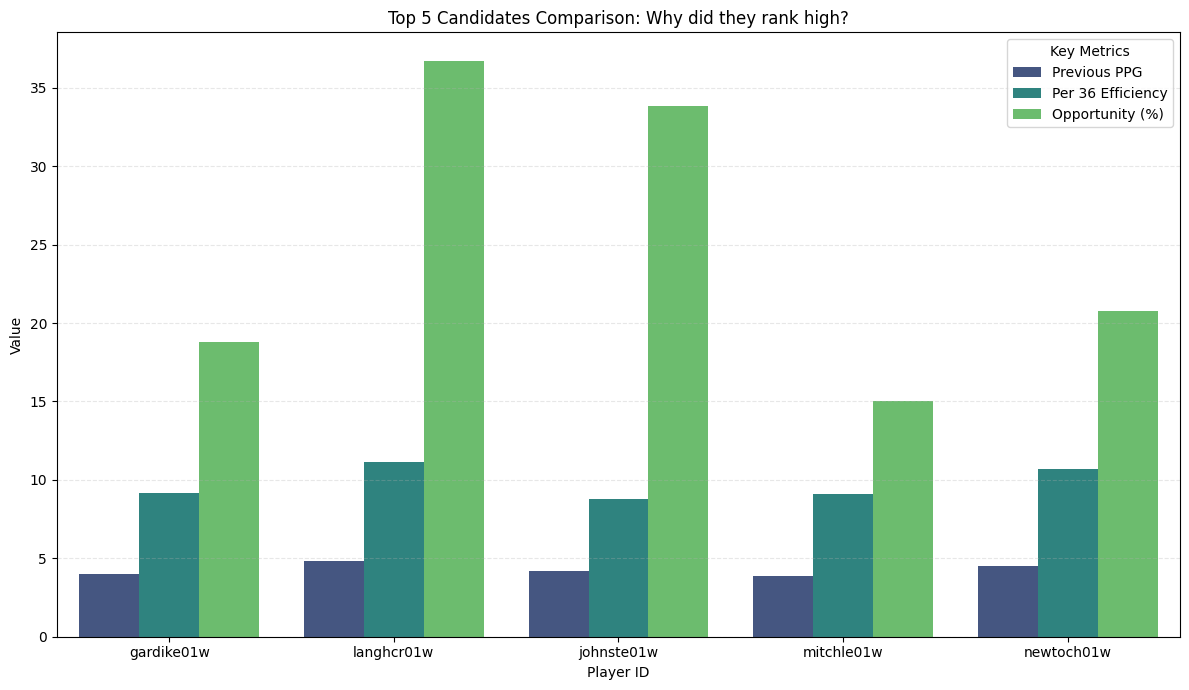

In [ ]:
# New Feature Set includes Per36 and Production Per Minute
features = [
    'prev_ppg', 'prev_mpg', 
    'prev_per36_pts', 'prev_prod_per_minute',
    'age', 'experience', 'is_sophomore',     
    'vacated_min_pct', 'new_coach'
]

df_final[features] = df_final[features].fillna(0)

train = df_final[df_final['year'] < 10]
test = df_final[df_final['year'] == 10]

# Target: Did they win THIS year?
current_winners = mip_winners[['playerID', 'year']].copy()
current_winners['won'] = 1
train = pd.merge(train, current_winners[['playerID', 'year', 'won']], on=['playerID', 'year'], how='left')
train['won'] = train['won'].fillna(0)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, max_depth=10)
rf.fit(train[features], train['won'])

test = test.copy()
test['prob'] = rf.predict_proba(test[features])[:, 1]

# Get Top 5 Predictions
top5 = test.sort_values('prob', ascending=False).head(5)
print("\n>>> Top 5 Predictions Year 10:")
print(top5[['playerID', 'prob', 'prev_ppg', 'prev_per36_pts', 'vacated_min_pct']])

# Prepare data for plotting
plot_data = top5[['playerID', 'prev_ppg', 'prev_per36_pts', 'vacated_min_pct']].copy()
# Scale vacated_min_pct to be visible alongside PPG (multiply by 100 for percentage)
plot_data['vacated_pct_scaled'] = plot_data['vacated_min_pct'] * 100

# Melt for grouped bar chart
df_melted = plot_data.melt(id_vars='playerID', 
                           value_vars=['prev_ppg', 'prev_per36_pts', 'vacated_pct_scaled'],
                           var_name='Metric', value_name='Value')

# Rename metrics for cleaner legend
metric_labels = {
    'prev_ppg': 'Previous PPG',
    'prev_per36_pts': 'Per 36 Efficiency',
    'vacated_pct_scaled': 'Opportunity (%)'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x='playerID', y='Value', hue='Metric', data=df_melted, palette='viridis')

plt.title('Top 5 Candidates Comparison: Why did they rank high?')
plt.ylabel('Value')
plt.xlabel('Player ID')
plt.legend(title='Key Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()


#### Kim Perrot Sportsmanship Award

In [79]:
import pandas as pd
import numpy as np

# Load Data
kpsa_df = pd.read_csv('../dataset_for_modeling/kim_perrot_sportsmanship_award_features.csv')
players = pd.read_csv("../dataset_cleaned/players.csv")
players_teams = pd.read_csv("../dataset_cleaned/players_teams.csv")

# -------------------------------------------------------------------------
# Feature Engineering
# -------------------------------------------------------------------------

# --- Age Proxy (Logarithmic) ---
players['birthDate'] = pd.to_datetime(players['birthDate'], errors='coerce')
players['birth_year'] = players['birthDate'].dt.year

kpsa_df = kpsa_df.merge(players[['bioID', 'birth_year', 'pos']], left_on='playerID', right_on='bioID', how='left')
kpsa_df['age_raw'] = 2025 - kpsa_df['birth_year']
# Use Log to smooth the impact of age (diminishing returns for very old players)
kpsa_df['age_proxy'] = np.log(kpsa_df['age_raw']) 
kpsa_df['age_proxy'] = kpsa_df['age_proxy'].fillna(kpsa_df['age_proxy'].mean())

# --- Position (Guard) ---
kpsa_df['is_guard'] = kpsa_df['pos'].str.contains('G', na=False).astype(int)

# --- Team Tenure (Loyalty) ---
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])
kpsa_df['team_tenure'] = kpsa_df.groupby(['playerID', 'tmID']).cumcount() + 1

# Consolidate stats from players_teams (GS, GP, Steals, Blocks, PF, Minutes)
pt_stats = players_teams.groupby(['playerID', 'year', 'tmID'])[[
    'GS', 'GP', 'steals', 'blocks', 'PF', 'minutes'
]].sum().reset_index()

kpsa_df = kpsa_df.merge(pt_stats, on=['playerID', 'year', 'tmID'], how='left')

# --- Starter Ratio ---
# Measure of starter status (0.0 to 1.0)
kpsa_df['starter_ratio'] = kpsa_df['GS'] / (kpsa_df['GP'] + 1)
kpsa_df['starter_ratio'] = kpsa_df['starter_ratio'].fillna(0)

# --- Clean Defense Ratio ---
# (Steals + Blocks) / (Fouls + 1) -> Square Root to smooth outliers
kpsa_df['clean_defense'] = (kpsa_df['steals'] + kpsa_df['blocks']) / (kpsa_df['PF'] + 1)
kpsa_df['clean_defense'] = kpsa_df['clean_defense'].fillna(0)
kpsa_df['clean_defense'] = np.sqrt(kpsa_df['clean_defense'])

# --- Minutes Per Game ---
# Volume measure -> Log to reduce gap between stars and rotation players
kpsa_df['minutes_per_game'] = kpsa_df['minutes'] / (kpsa_df['GP'] + 1)
kpsa_df['minutes_per_game'] = kpsa_df['minutes_per_game'].fillna(0)
kpsa_df['minutes_per_game'] = np.log1p(kpsa_df['minutes_per_game'])

kpsa_df.fillna(0, inplace=True)

# -------------------------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# -------------------------------------------------------------------------

all_stats_columns = [
    "fouls_per_game", "fouls_per_36", "disqualifications",
    "assist_to_turnover", "turnovers_per_game", "turnovers_per_36",
    "assists_per_game", "assists_per_36", "positive_actions",
    "positive_actions_per_game",
    "in_team_fouls_pct", "in_team_to_pct", "in_team_ast_pct", "in_team_dq_pct",
    "stint", "age_proxy", "is_guard", "starter_ratio", "team_tenure", 
    "clean_defense", "minutes_per_game"
]

yearly_means = kpsa_df.groupby('year')[all_stats_columns].mean()
winners = kpsa_df[kpsa_df['is_kpsa'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']
    
    print(f"\n----------------------------------------------------------------")
    print(f"YEAR {year}: Winner {player_id} ({tm_id})")
    print(f"----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)
    
    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]
        
        # Calculate percentage difference
        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100
            
        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

# -------------------------------------------------------------------------
# Feature Groups Definition
# -------------------------------------------------------------------------

# Features that change every year (require history/lags)
dynamic_features = [
    'fouls_per_36', 'disqualifications', 'assist_to_turnover',
    'turnovers_per_game', 'turnovers_per_36', 'positive_actions',
    'in_team_ast_pct', 'in_team_to_pct', 'assists_per_game',
    'starter_ratio', 'stint', 'minutes_per_game', 'clean_defense'
]

# Features that are known/static at the start of the season
static_features = [
    'age_proxy', 'is_guard', 'team_tenure'
]



=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Winner mcconsu01w (CLE)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
fouls_per_game                 |     0.94 |       1.88 |     -50.2%
fouls_per_36                   |     1.53 |       4.39 |     -65.1%
disqualifications              |     0.00 |       0.50 |    -100.0%
assist_to_turnover             |     1.70 |       0.89 |     +90.6%
turnovers_per_game             |     2.16 |       1.38 |     +55.8%
turnovers_per_36               |     3.52 |       2.93 |     +20.1%
assists_per_game               |     3.72 |       1.38 |    +169.1%
assists_per_36                 |     6.08 |       2.67 |    +127.7%
positive_actions               |   185.00 |     140.21 |     +31.9%
positive_actions_per_game  

In [80]:
# Initialize feature lists
z_features_dynamic = []
z_features_static = []

# ---------------------------------------------------------
# Standardization (Z-Scores)
# ---------------------------------------------------------

# Helper lambda for robust Z-score (avoids division by zero)
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

# Calculate Z-scores for Dynamic Features (grouped by year)
for col in dynamic_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_dynamic.append(new_col)

# Calculate Z-scores for Static Features (grouped by year)
for col in static_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_static.append(new_col)

# Sort ensures time-series operations (shift/rolling) are correct
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])

# ---------------------------------------------------------
# Dynamic Feature Engineering
# ---------------------------------------------------------

# Create Lag-1 Features
lag_cols = [f"{col}_lag1" for col in z_features_dynamic]
kpsa_df[lag_cols] = kpsa_df.groupby('playerID')[z_features_dynamic].shift(1)

# Create 3-Year Weighted Rolling Average
def weighted_avg_robust(series):
    """
    Calculates a weighted average for a window size up to 3.
    Weights: 0.2 (t-2), 0.3 (t-1), 0.5 (t).
    Handles NaN values by re-normalizing weights.
    """
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    
    # Adjust weights if the window is smaller than 3 (e.g., start of career)
    w = weights[-len(s):]
    
    mask = ~np.isnan(s)
    if not np.any(mask): 
        return np.nan
        
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

# Define names for the average columns
avg_cols = [f"{col}_avg3yr" for col in z_features_dynamic]

# Apply rolling window on the LAGGED columns
rolling_stats = kpsa_df.groupby('playerID')[lag_cols] \
                       .rolling(window=3, min_periods=1) \
                       .apply(weighted_avg_robust, raw=True)

# Align index to assign back to dataframe
kpsa_df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

current_static_cols = z_features_static

# Remove rows where historical performance data (Lags) is missing
model_df_c = kpsa_df.dropna(subset=lag_cols)

# Combine all features: Performance History + Current Context
features_final_c = lag_cols + avg_cols + current_static_cols
target_c = 'is_kpsa'


In [84]:
# ---------------------------------------------------------
# Temporal split + baseline
# ---------------------------------------------------------
train_df = model_df_c[model_df_c["year"] < 9]
val_df   = model_df_c[model_df_c["year"] == 9]
test_df  = model_df_c[model_df_c["year"] == 10]

X_train, y_train = train_df[features_final_c], train_df[target_c]
X_val,   y_val   = val_df[features_final_c],   val_df[target_c]
X_test,  y_test  = test_df[features_final_c],  test_df[target_c]

print(f"Training Samples: {len(X_train)} | Winners in Train: {y_train.sum()}")

K = 5

def build_baseline_score(df):
    score = (
        -df["z_fouls_per_36_lag1"].fillna(0) * 0.5
        -df["z_turnovers_per_36_lag1"].fillna(0) * 0.3
        +df["z_assist_to_turnover_lag1"].fillna(0) * 0.2
    )
    return score

val_baseline = val_df[["playerID", "tmID", "is_kpsa"]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))

if (val_baseline["is_kpsa"] == 1).any():
    kpsa_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline["is_kpsa"] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{kpsa_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", "is_kpsa"]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))

if (test_baseline["is_kpsa"] == 1).any():
    kpsa_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline["is_kpsa"] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{kpsa_rank_baseline_test}")
    

Training Samples: 1030 | Winners in Train: 7

--- Baseline ranking (Year 9) ---
  playerID tmID  is_kpsa  baseline_score
johnsvi01w  SAS        1        1.204234
smithcr01w  WAS        0        1.184561
sharpkb01w  CHI        0        0.998789
 birdsu01w  SEA        0        0.952433
philler01w  CON        0        0.935662
Baseline winner rank (validation): #1

--- Baseline ranking (Year 10) ---
  playerID tmID  is_kpsa  baseline_score
johnsvi01w  SAS        0        1.199254
hodgero01w  MIN        0        1.192183
 mannkr01w  WAS        0        1.122632
mazzake01w  PHO        0        1.121518
deforan01w  DET        0        1.064676
Baseline winner rank (test): #14


In [86]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search)
# ---------------------------------------------------------
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced"
        ),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)

print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))



--- Grid Search on TRAIN only (years < 9) for 3 models ---

Training RandomForest...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8936
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training GradientBoosting...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
  > Best ROC AUC (CV on train): 0.9571
  > Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}

Training LogisticRegression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  > Best ROC AUC (CV on train): 0.9210
  > Best Params: {'model__C': 10.0}

--- Tuned models (CV on train) ---
             Model  CV AUC (train)                                                                                                                     Best_Params
  GradientBoosting        0.957071                                       

In [87]:
# ---------------------------------------------------------
# Validation Analysis (Year 9)
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", "is_kpsa"]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k["is_kpsa"].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Top 5 Favorites Predicted by Model:")
print(best_val_results.head(5).to_string(index=False))

actual_winner_row = best_val_results[best_val_results["is_kpsa"] == 1]
if not actual_winner_row.empty:
    winner_rank = best_val_results.index.get_loc(actual_winner_row.index[0]) + 1
    winner_name = actual_winner_row["playerID"].values[0]
    winner_prob = actual_winner_row.iloc[0]["prob_winning"]
    top_prob = best_val_results.iloc[0]["prob_winning"]

    print(f"\nActual Winner ({winner_name}) Rank: #{winner_rank}")
    print(f"Winner Probability: {winner_prob:.4f} (Top Favorite: {top_prob:.4f})")
else:
    print("\nActual Winner not found in validation set.")

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", "is_kpsa"]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k["is_kpsa"].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

print("\n--- TEST PREDICTION (Year 10) ---")
print(f"Model's Top 5 Candidates ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

# Check where the actual winner landed in the rankings (Year 10)
actual_test_winner_row = final_results_test[final_results_test["is_kpsa"] == 1]
if not actual_test_winner_row.empty:
    winner_rank_test = final_results_test.index.get_loc(actual_test_winner_row.index[0]) + 1
    winner_name_test = actual_test_winner_row["playerID"].values[0]
    winner_prob_test = actual_test_winner_row.iloc[0]["prob_winning"]
    top_prob_test = final_results_test.iloc[0]["prob_winning"]

    print(f"\nActual Winner ({winner_name_test}) Rank (Year 10): #{winner_rank_test}")
    print(f"Winner Probability: {winner_prob_test:.4f} (Top Favorite: {top_prob_test:.4f})")
else:
    print("\nActual Winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")

# ---------------------------------------------------------
# Detailed Error Analysis (Head-to-Head)
# ---------------------------------------------------------
actual_test_winner_row = final_results_test[final_results_test["is_kpsa"] == 1]

if not actual_test_winner_row.empty:
    rank_10 = final_results_test.index.get_loc(actual_test_winner_row.index[0]) + 1
    print(f"\nYear 10 Real Winner Rank: #{rank_10}")

    winner_idx = actual_test_winner_row.index[0]
    favorite_idx = final_results_test.index[0]

    winner_id = actual_test_winner_row["playerID"].values[0]
    favorite_id = final_results_test.iloc[0]["playerID"]

    print(f"\n--- Head-to-Head: Actual Winner ({winner_id}) vs Model Favorite ({favorite_id}) ---")
    print("Comparing feature inputs (Positive Diff = Favorite has higher value):")

    comp_df = pd.DataFrame({
        f"WINNER ({winner_id})": X_test.loc[winner_idx],
        f"FAVORITE ({favorite_id})": X_test.loc[favorite_idx]
    })

    comp_df["Diff (Fav - Win)"] = comp_df.iloc[:, 1] - comp_df.iloc[:, 0]

    prob_row = pd.DataFrame({
        f"WINNER ({winner_id})": [actual_test_winner_row["prob_winning"].values[0]],
        f"FAVORITE ({favorite_id})": [final_results_test.iloc[0]["prob_winning"]],
        "Diff (Fav - Win)": [
            final_results_test.iloc[0]["prob_winning"] -
            actual_test_winner_row["prob_winning"].values[0]
        ]
    }, index=[">> PREDICTED PROBABILITY"])

    final_comp = pd.concat([prob_row, comp_df])
    print(final_comp.round(4))
else:
    print("\nActual Winner not found in test set.")
    


--- Validation performance (Year 9) for tuned models ---

--- Model ranking on Validation (Year 9) ---
             Model  Val AUC   Val AP  Top-5 hit (val)
      RandomForest 1.000000 1.000000                1
  GradientBoosting 1.000000 1.000000                1
LogisticRegression 0.826667 0.037037                0

Best model on validation: RandomForest

--- Validation Results (Year 9) ---
Top 5 Favorites Predicted by Model:
  playerID tmID  is_kpsa  prob_winning
johnsvi01w  SAS        1      0.223544
mcwilta01w  WAS        0      0.206405
swoopsh01w  SEA        0      0.190711
beviltu01w  IND        0      0.190075
griffyo01w  SEA        0      0.105522

Actual Winner (johnsvi01w) Rank: #1
Winner Probability: 0.2235 (Top Favorite: 0.2235)

--- Evaluating tuned models retrained on TRAIN+VAL ---

--- Final comparison on Test (Year 10) ---
             Model  Test AUC  Test AP  Top-5 hit (test)
      RandomForest  0.870504 0.052632                 0
LogisticRegression  0.705036 0.023


=== Logistic Regression coefficients (white-box) ===
z_age_proxy                    8.205641
z_positive_actions_avg3yr     -7.161587
z_in_team_ast_pct_lag1        -4.521194
z_clean_defense_lag1           4.287011
z_in_team_to_pct_lag1          4.042262
z_positive_actions_lag1        3.970444
z_turnovers_per_game_lag1     -3.749919
z_turnovers_per_game_avg3yr   -3.216146
z_assists_per_game_avg3yr      2.899776
z_minutes_per_game_avg3yr      2.724543
z_turnovers_per_36_avg3yr      2.247384
z_minutes_per_game_lag1        2.091941
z_assist_to_turnover_avg3yr    1.941733
z_fouls_per_36_lag1           -1.928075
z_disqualifications_lag1       1.908043
dtype: float64


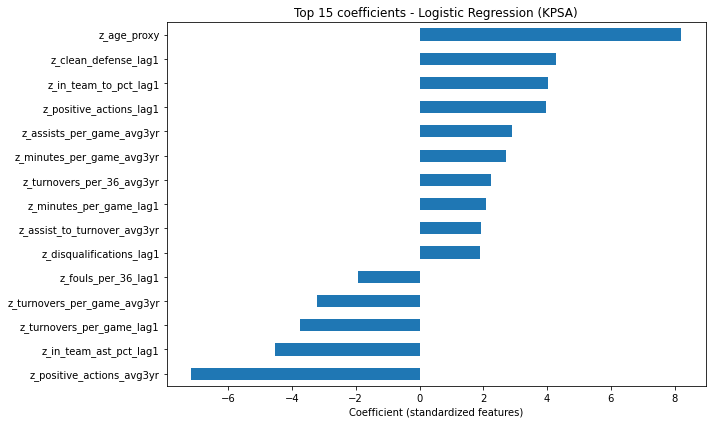


Top 15 Most Important Features (final model):
                    Feature  Importance
                z_age_proxy    0.332698
       z_clean_defense_lag1    0.081270
     z_starter_ratio_avg3yr    0.054735
     z_clean_defense_avg3yr    0.050113
  z_minutes_per_game_avg3yr    0.046548
              z_team_tenure    0.043225
      z_fouls_per_36_avg3yr    0.030178
        z_fouls_per_36_lag1    0.025713
  z_turnovers_per_36_avg3yr    0.023995
  z_positive_actions_avg3yr    0.023333
    z_assists_per_game_lag1    0.023061
    z_turnovers_per_36_lag1    0.022104
    z_minutes_per_game_lag1    0.021578
z_turnovers_per_game_avg3yr    0.020336
z_assist_to_turnover_avg3yr    0.018743


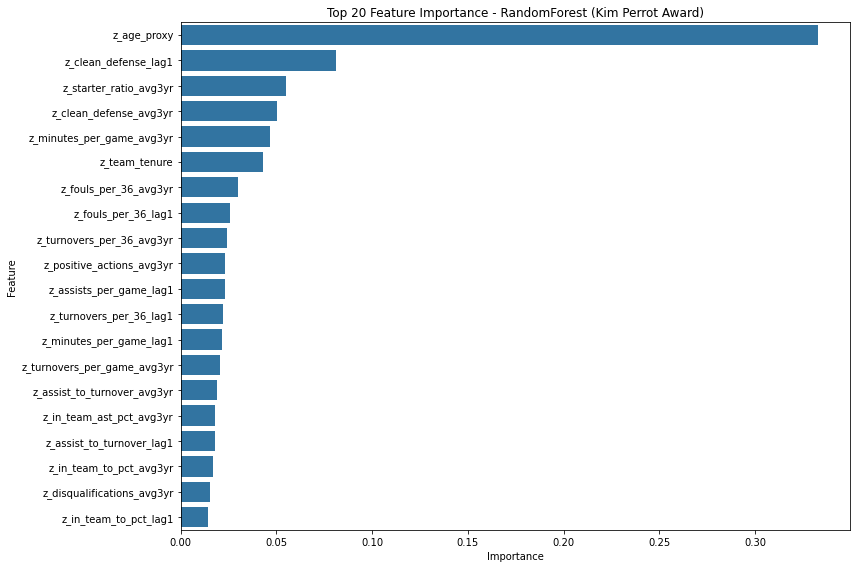

In [88]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final_c).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (KPSA)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final_c

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(feature_importance_df.head(15).to_string(index=False))

    plt.figure(figsize=(12, 8))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance_df.head(20)
    )
    plt.title(f"Top 20 Feature Importance - {final_model_name} (Kim Perrot Award)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


#### Defensive Player of the Year Award

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load Data
df = pd.read_csv('../dataset_for_modeling/defensive_player_of_year_features.csv')
teams = pd.read_csv('../dataset_cleaned/teams.csv')

teams['win_pct'] = teams['won'] / teams['GP']
teams['ppg_allowed'] = teams['d_pts'] / teams['GP']
teams['team_def_rank'] = teams.groupby('year')['ppg_allowed'].rank(ascending=True)

team_stats = teams[['year', 'tmID', 'win_pct', 'team_def_rank']]
df = df.merge(team_stats, on=['year', 'tmID'], how='left')

df = df.sort_values(['playerID', 'year'])
df['experience'] = df.groupby('playerID').cumcount()

# -------------------------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# -------------------------------------------------------------------------
all_stats_columns = [
    "steals_per_game", "blocks_per_game", "def_reb_per_game",
    "steals_per_36", "blocks_per_36", "def_reb_per_36",
    "def_reb_pct", "steals_pct", "blocks_pct",
    "def_stocks", "def_stocks_per_game", "def_stocks_per_36", "def_stocks_pct",
    "def_versatility", "def_versatility_per_game", "def_versatility_per_36", "def_versatility_pct",
    "fouls_per_game", "fouls_per_36",
    "stocks_to_fouls_ratio", "steals_to_fouls_ratio",
    "minutes_per_game", "games_started_pct", "games_played_pct",
    "turnovers_per_game", "assist_to_steal_ratio", "block_to_steal_ratio",
    "in_team_blk_pct", "in_team_stl_pct", "in_team_dreb_pct",
    "win_pct", "team_def_rank", "experience"
]

# Calculate League Averages per Year
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter Winners
winners = df[df['is_dpoy'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']
    
    print(f"\n----------------------------------------------------------------")
    print(f"YEAR {year}: Winner {player_id} ({tm_id})")
    print(f"----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)
    
    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]
        
        # Calculate percentage difference
        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100
            
        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

selected_features = [
    "steals_per_game", "blocks_per_game", "def_reb_per_game",
    "def_stocks_per_game", "stocks_to_fouls_ratio", "minutes_per_game",
    "games_started_pct", "turnovers_per_game", "in_team_blk_pct",
    "in_team_stl_pct", "in_team_dreb_pct", "win_pct", "team_def_rank"
]



=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Winner swoopsh01w (HOU)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
steals_per_game                |     2.81 |       0.72 |    +292.2%
blocks_per_game                |     1.06 |       0.29 |    +268.8%
def_reb_per_game               |     5.00 |       1.79 |    +179.9%
steals_per_36                  |     2.87 |       1.35 |    +113.0%
blocks_per_36                  |     1.09 |       0.51 |    +113.2%
def_reb_per_36                 |     5.12 |       3.64 |     +40.6%
def_reb_pct                    |     0.79 |       0.67 |     +18.4%
steals_pct                     |     0.08 |       0.04 |    +113.0%
blocks_pct                     |     0.03 |       0.01 |    +113.2%
def_stocks                 

In [72]:
# ---------------------------------------------------------
# Standardization (Z-Scores)
# ---------------------------------------------------------
z_features = []
# Helper lambda for robust Z-score (prevents division by zero)
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

# Calculate Z-scores (grouped by year to account for different eras/pace)
for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Sort strictly by Player and Year for time-series operations
df = df.sort_values(['playerID', 'year'])

# Lag-1 (Performance from the previous year)
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('playerID')[z_features].shift(1)

# 3-Year Weighted Rolling Average
def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask): 
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = df.groupby('playerID')[lag_cols] \
                  .rolling(window=3, min_periods=1) \
                  .apply(weighted_avg_robust, raw=True)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

features_final = lag_cols + avg_cols + ["experience"]
target = 'is_dpoy'

# We need at least 1 year of history for lags, so we drop NaNs in lag_cols.
# This removes Rookies (Year 1) from the training, which is acceptable for DPOY.
model_df = df.dropna(subset=lag_cols)

print(f"Total Features for Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")


Total Features for Model: 27
Example Features: ['z_steals_per_game_lag1', 'z_blocks_per_game_lag1', 'z_def_reb_per_game_lag1'] ...
Rows ready for training: 1321


In [73]:
# ---------------------------------------------------------
# Temporal Data Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"Training Samples: {len(X_train)} | Positive Cases (Winners): {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # for Top-K hit

# ---------------------------------------------------------
# Baseline (simple defensive stocks heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_def_stocks_per_game_lag1"].fillna(0) * 1.0
        - df_["z_team_def_rank_lag1"].fillna(0) * 0.3
    )
    return score

val_baseline = val_df[["playerID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    dpoy_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{dpoy_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    dpoy_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{dpoy_rank_baseline_test}")
    

Training Samples: 1030 | Positive Cases (Winners): 7
Validation Samples: 151 | Test Samples: 140

--- Baseline ranking (Year 9) ---
  playerID tmID  is_dpoy  baseline_score
catchta01w  IND        0        4.754916
leslili01w  LAS        1        3.135874
rileyru01w  SAS        0        2.806016
jacksla01w  SEA        0        2.453807
suttota01w  IND        0        2.357216
Baseline winner rank (validation): #2

--- Baseline ranking (Year 10) ---
  playerID tmID  is_dpoy  baseline_score
leslili01w  LAS        0        4.350953
parkeca01w  LAS        0        3.260363
fowlesy01w  CHI        0        3.025169
jacksla01w  SEA        0        3.016841
anosini01w  MIN        0        2.718294
Baseline winner rank (test): #8


In [74]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced"
        ),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)

print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["playerID"].values[0]
    print(f"\nYear 9 Actual Winner ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual Winner not found in validation set (filtered out?).")

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_10 = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id = actual_winner_test["playerID"].values[0]
    print(f"\nYear 10 Actual Winner ({winner_id}) Rank: #{rank_10}")
    print(f"   Probability: {actual_winner_test['prob_winning'].values[0]:.4f}")
else:
    print("\nActual Winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")



--- Grid Search on TRAIN only (years < 9) for 3 models ---

Training RandomForest...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8275
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Training XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  > Best ROC AUC (CV on train): 0.8379
  > Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Training LogisticRegression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  > Best ROC AUC (CV on train): 0.8913
  > Best Params: {'model__C': 0.01}

--- Tuned models (CV on train) ---
             Model  CV AUC (train)                                                                                                                                Best_Params
LogisticRegress


=== Logistic Regression coefficients (white-box) ===
z_def_stocks_per_game_avg3yr    0.356734
z_in_team_stl_pct_avg3yr        0.316221
z_team_def_rank_lag1           -0.300137
z_steals_per_game_avg3yr        0.283097
z_team_def_rank_avg3yr         -0.255058
z_blocks_per_game_avg3yr        0.235211
z_def_stocks_per_game_lag1      0.232969
z_turnovers_per_game_lag1      -0.225401
z_games_started_pct_avg3yr      0.197238
z_steals_per_game_lag1          0.180414
z_def_reb_per_game_avg3yr       0.175917
z_in_team_stl_pct_lag1          0.174362
z_blocks_per_game_lag1          0.166947
z_in_team_dreb_pct_avg3yr       0.159349
z_games_started_pct_lag1        0.146108
dtype: float64


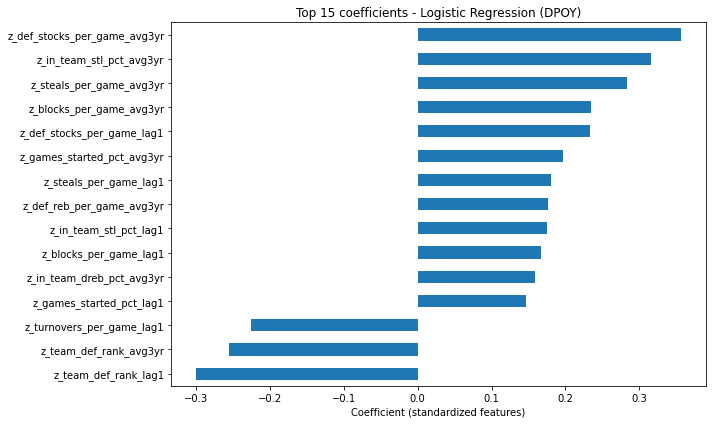


Top 15 Most Important Features (final model):
                       Feature  Importance
  z_def_stocks_per_game_avg3yr    0.143546
    z_def_stocks_per_game_lag1    0.134416
     z_in_team_dreb_pct_avg3yr    0.130223
      z_steals_per_game_avg3yr    0.071837
       z_def_reb_per_game_lag1    0.067305
        z_steals_per_game_lag1    0.064853
z_stocks_to_fouls_ratio_avg3yr    0.059128
      z_in_team_stl_pct_avg3yr    0.046290
    z_games_started_pct_avg3yr    0.036983
     z_def_reb_per_game_avg3yr    0.036921
      z_in_team_blk_pct_avg3yr    0.029721
  z_stocks_to_fouls_ratio_lag1    0.026119
     z_minutes_per_game_avg3yr    0.024696
   z_turnovers_per_game_avg3yr    0.022347
       z_in_team_dreb_pct_lag1    0.021726


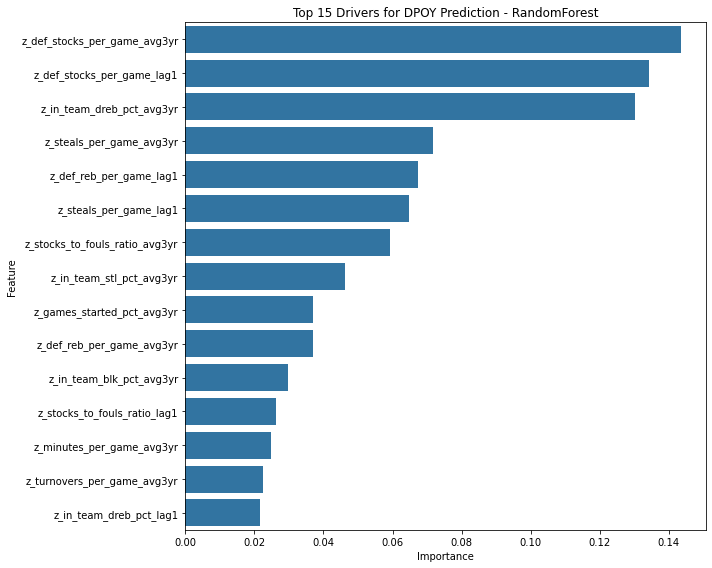

In [76]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (DPOY)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for DPOY Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


#### WNBA Final MVP Award

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load Data
df = pd.read_csv('../dataset_for_modeling/wnba_finals_mvp_features.csv')
teams = pd.read_csv('../dataset_cleaned/teams.csv')

# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------

teams['win_pct'] = teams['won'] / teams['GP']

team_stats = teams[['year', 'tmID', 'win_pct']]
df = df.merge(team_stats, on=['year', 'tmID'], how='left')

df = df.sort_values(['playerID', 'year'])

df['experience'] = df.groupby('playerID').cumcount()

# ---------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# ---------------------------------------------------------

all_stats_columns = [
    "playoff_points_per_game",
    "playoff_rebounds_per_game",
    "playoff_assists_per_game",
    "playoff_steals_per_game",
    "playoff_blocks_per_game",
    "playoff_points_per_36",
    "playoff_rebounds_per_36",
    "playoff_assists_per_36",
    "playoff_fg_pct",
    "playoff_three_pct",
    "playoff_ft_pct",
    "playoff_impact",
    "playoff_impact_per_game",
    "playoff_minutes_per_game",
    "playoff_games_started_pct",
    "playoff_ast_to_ratio",
    "playoff_turnover_per_game",
    "is_champion",
    "win_pct",
    "experience"
]

# League averages per year
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter Finals MVP winners
winners = df[df['is_finals_mvp'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: FINALS MVP vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']

    print("\n----------------------------------------------------------------")
    print(f"YEAR {year}: Finals MVP {player_id} ({tm_id})")
    print("----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)

    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]

        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100

        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

# ---------------------------------------------------------
# Feature Set for Modeling
# ---------------------------------------------------------

selected_features = [
    "playoff_points_per_game",
    "playoff_impact_per_game",
    "playoff_minutes_per_game",
    "playoff_games_started_pct",
    "playoff_rebounds_per_game",
    "playoff_assists_per_game",
    "playoff_steals_per_game",
    "playoff_blocks_per_game",
    "playoff_fg_pct",
    "win_pct"
]

target = "is_finals_mvp"



=== DETAILED ANALYSIS: FINALS MVP vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Finals MVP coopecy01w (HOU)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
playoff_points_per_game        |    22.67 |       5.66 |    +300.5%
playoff_rebounds_per_game      |     2.50 |       2.42 |      +3.1%
playoff_assists_per_game       |     3.67 |       1.14 |    +223.0%
playoff_steals_per_game        |     1.50 |       0.76 |     +96.6%
playoff_blocks_per_game        |     0.17 |       0.23 |     -27.4%
playoff_points_per_36          |    21.47 |       9.93 |    +116.4%
playoff_rebounds_per_36        |     2.37 |       4.29 |     -44.8%
playoff_assists_per_36         |     3.47 |       1.70 |    +104.1%
playoff_fg_pct                 |     0.38 |       0.35 |      +7.2%
playoff_three_pct  

In [67]:
# ---------------------------------------------------------
# Standardization (Per-year Z-scores)
# ---------------------------------------------------------
z_features = []
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Ensure strictly sorted for time-series ops
df = df.sort_values(['playerID', 'year'])

# ---------------------------------------------------------
# Lag-1 and 3-Year Weighted Rolling Averages
# ---------------------------------------------------------

# Lag-1: previous-year standardized performance
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('playerID')[z_features].shift(1)

# 3-year weighted rolling average on lagged z-features
def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask):
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = (
    df.groupby('playerID')[lag_cols]
      .rolling(window=3, min_periods=1)
      .apply(weighted_avg_robust, raw=True)
)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

# Final feature set: ONLY lag + avg variants + narrative + experience
features_final = lag_cols + avg_cols + ["experience"]

# Need at least 1 year of history → drop rows with missing lags
model_df = df.dropna(subset=lag_cols)

print(f"\nTotal Features for Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")



Total Features for Model: 21
Example Features: ['z_playoff_points_per_game_lag1', 'z_playoff_impact_per_game_lag1', 'z_playoff_minutes_per_game_lag1'] ...
Rows ready for training: 81


In [68]:
# ---------------------------------------------------------
# Temporal Train / Val / Test Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"\nTraining Samples: {len(X_train)} | Positive Cases (FMVP): {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # Top-K hit

# ---------------------------------------------------------
# Baseline (simple Finals MVP heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_playoff_points_per_game_lag1"].fillna(0) * 0.6
        + df_["z_playoff_impact_per_game_lag1"].fillna(0) * 0.4
        + df_["z_win_pct_lag1"].fillna(0) * 0.3
    )
    return score

val_baseline = val_df[["playerID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    fmvp_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{fmvp_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    fmvp_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{fmvp_rank_baseline_test}")
    


Training Samples: 56 | Positive Cases (FMVP): 2
Validation Samples: 13 | Test Samples: 12

--- Baseline ranking (Year 9) ---
  playerID tmID  is_finals_mvp  baseline_score
mcwilta01w  DET              0        2.130814
nolande01w  DET              0        1.947114
smithka01w  DET              1        1.048438
pierspl01w  DET              0        1.027583
  samsh01w  DET              0        0.712321
Baseline winner rank (validation): #3

--- Baseline ranking (Year 10) ---
  playerID tmID  is_finals_mvp  baseline_score
pondeca01w  PHO              0        1.945840
taylope01w  PHO              0        1.510799
tauradi01w  PHO              1        1.407577
douglka01w  IND              0        1.327008
griffyo01w  IND              0        1.158636
Baseline winner rank (test): #3


In [69]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced"
        ),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

n_pos_train = int(y_train.sum())
print("Positives in train:", n_pos_train)

n_splits = 2 if n_pos_train < 3 else 3

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)

print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["playerID"].values[0]
    print(f"\nYear 9 Actual FMVP ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual Finals MVP not found in validation set (may have been filtered out).")

# ---------------------------------------------------------
# Detailed comparison: Top 2 vs actual FMVP (Year 9)
# ---------------------------------------------------------
year_to_inspect = 9

top2 = best_val_results.head(2).copy()
top2_ids = top2["playerID"].tolist()
top2_tmids = top2["tmID"].tolist()

true_winner_row = df[(df["year"] == year_to_inspect) & (df[target] == 1)].iloc[0]
true_winner_id = true_winner_row["playerID"]
true_winner_tmid = true_winner_row["tmID"]

print(f"\n=== DETAILED FEATURE COMPARISON – YEAR {year_to_inspect} ===")
print(f"Model Top 1: {top2_ids[0]} ({top2_tmids[0]})")
print(f"Model Top 2: {top2_ids[1]} ({top2_tmids[1]})")
print(f"Actual FMVP: {true_winner_id} ({true_winner_tmid})")

print("\n{:<30} | {:>10} | {:>10} | {:>10}".format(
    "FEATURE", "TOP1", "TOP2", "FMVP"
))
print("-" * 70)

year9_df = df[df["year"] == year_to_inspect]

row_top1 = year9_df[year9_df["playerID"] == top2_ids[0]].iloc[0]
row_top2 = year9_df[year9_df["playerID"] == top2_ids[1]].iloc[0]
row_fmvp = year9_df[year9_df["playerID"] == true_winner_id].iloc[0]

for col in features_final:
    v1 = row_top1[col]
    v2 = row_top2[col]
    vw = row_fmvp[col]
    print("{:<30} | {:>10.2f} | {:>10.2f} | {:>10.2f}".format(col, v1, v2, vw))

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10 Forecast) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_test = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id_test = actual_winner_test["playerID"].values[0]
    prob_test = actual_winner_test["prob_winning"].values[0]
    print(f"\nYear 10 Actual FMVP ({winner_id_test}) Rank: #{rank_test}")
    print(f"   Predicted Probability: {prob_test:.4f}")
else:
    print("\nActual Finals MVP not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")



--- Grid Search on TRAIN only (years < 9) for 3 models ---
Positives in train: 2

Training RandomForest...
Fitting 2 folds for each of 54 candidates, totalling 108 fits


  > Best ROC AUC (CV on train): 0.8519
  > Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training XGBoost...
Fitting 2 folds for each of 32 candidates, totalling 64 fits
  > Best ROC AUC (CV on train): 0.9444
  > Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Training LogisticRegression...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
  > Best ROC AUC (CV on train): 0.8704
  > Best Params: {'model__C': 0.01}

--- Tuned models (CV on train) ---
             Model  CV AUC (train)                                                                                                                                Best_Params
           XGBoost        0.944444 {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}



=== Logistic Regression coefficients (white-box) ===
z_playoff_points_per_game_avg3yr      0.115931
z_playoff_points_per_game_lag1        0.101360
z_win_pct_avg3yr                      0.095733
z_win_pct_lag1                        0.095359
z_playoff_games_started_pct_lag1      0.085942
z_playoff_minutes_per_game_avg3yr     0.083398
z_playoff_impact_per_game_avg3yr      0.079904
z_playoff_games_started_pct_avg3yr    0.078007
z_playoff_minutes_per_game_lag1       0.077608
z_playoff_impact_per_game_lag1        0.071058
z_playoff_assists_per_game_avg3yr     0.056584
z_playoff_fg_pct_avg3yr               0.055009
z_playoff_steals_per_game_lag1        0.051999
z_playoff_assists_per_game_lag1       0.046804
z_playoff_fg_pct_lag1                 0.040746
dtype: float64


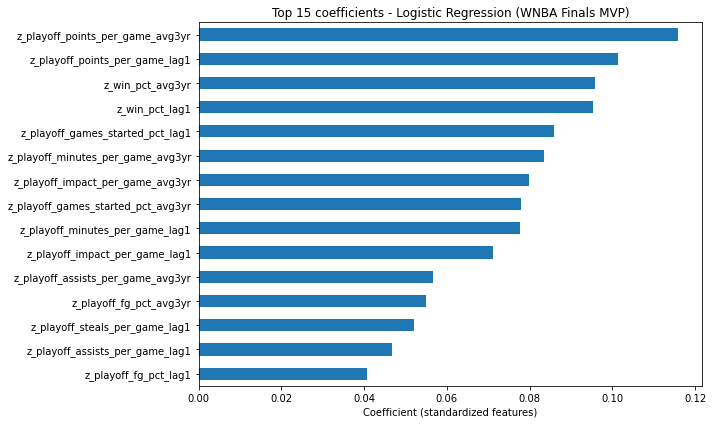


Top 15 Most Important Features (final model):
                           Feature  Importance
 z_playoff_minutes_per_game_avg3yr    0.140648
  z_playoff_points_per_game_avg3yr    0.108164
   z_playoff_minutes_per_game_lag1    0.098781
z_playoff_games_started_pct_avg3yr    0.075475
                    z_win_pct_lag1    0.066002
   z_playoff_assists_per_game_lag1    0.065862
    z_playoff_points_per_game_lag1    0.064149
 z_playoff_assists_per_game_avg3yr    0.049543
    z_playoff_steals_per_game_lag1    0.045652
  z_playoff_games_started_pct_lag1    0.045225
  z_playoff_impact_per_game_avg3yr    0.043212
  z_playoff_steals_per_game_avg3yr    0.031411
                  z_win_pct_avg3yr    0.030164
    z_playoff_impact_per_game_lag1    0.028006
  z_playoff_rebounds_per_game_lag1    0.025868


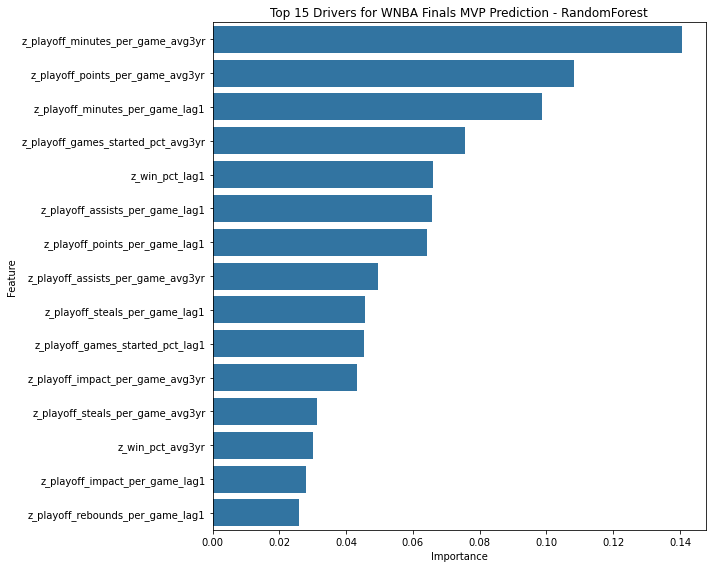

In [70]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (WNBA Finals MVP)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for WNBA Finals MVP Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    

#### Coach of the Year Award

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load Data
df = pd.read_csv('../dataset_for_modeling/coach_of_year_features.csv')

# Ensure sorted for time-based operations
df = df.sort_values(['coachID', 'year'])

# Experience: number of seasons this coach appears in dataset
df['experience'] = df.groupby('coachID').cumcount()

target = 'won_coy'

# ---------------------------------------------------------
# Comparison: COY vs League Average
# ---------------------------------------------------------

all_stats_columns = [
    # Coach performance
    'won_coach', 'lost_coach', 'win_percentage', 'total_games', 'stint',
    'post_wins', 'post_losses', 'playoff_games', 'playoff_win_pct', 'made_playoffs',

    # Team performance
    'rank', 'confW', 'confL', 'conference_win_pct',
    'homeW', 'homeL', 'home_win_pct',
    'awayW', 'awayL', 'away_win_pct', 'home_advantage',

    # Team stats
    'o_pts', 'd_pts', 'point_differential',
    'offensive_efficiency', 'defensive_efficiency', 'GP', 'attend',

    # Improvement metrics
    'prev_year_wins', 'prev_year_win_pct',
    'win_improvement', 'win_pct_improvement',
    'team_prev_wins', 'team_win_improvement',

    # Extra context
    'experience'
]

# League averages per year (only on numeric columns above)
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter COY winners
winners = df[df[target] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: COACH OF THE YEAR vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    coach_id = winners.loc[year, 'coachID']
    tm_id = winners.loc[year, 'tmID']

    print("\n----------------------------------------------------------------")
    print(f"YEAR {year}: COY {coach_id} ({tm_id})")
    print("----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>10} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 70)

    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]

        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100

        print(f"{col:<30} | {val_winner:>10.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")


# ---------------------------------------------------------
# Feature Set for Modeling
# ---------------------------------------------------------

selected_features = [
    'win_percentage', 'stint', 'playoff_win_pct', 'made_playoffs',
    'rank', 'confW', 'confL', 'conference_win_pct',
    'homeW', 'homeL', 'home_win_pct', 'away_win_pct', 'home_advantage',
    'offensive_efficiency', 'defensive_efficiency'
]

narrative_features = ['experience']



=== DETAILED ANALYSIS: COACH OF THE YEAR vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: COY coopemi01w (LAS)
----------------------------------------------------------------
FEATURE                        |     WINNER | LEAGUE AVG |     DIFF %
----------------------------------------------------------------------
won_coach                      |      28.00 |      15.06 |     +85.9%
lost_coach                     |       4.00 |      15.06 |     -73.4%
win_percentage                 |       0.88 |       0.50 |     +76.5%
total_games                    |      32.00 |      30.12 |      +6.3%
stint                          |       0.00 |       0.18 |    -100.0%
post_wins                      |       2.00 |       0.94 |    +112.5%
post_losses                    |       2.00 |       0.94 |    +112.5%
playoff_games                  |       4.00 |       1.88 |    +112.5%
playoff_win_pct                |       0.50 |       0.17 |    +1

In [90]:
# ---------------------------------------------------------
# Standardization (Per-year Z-scores)
# ---------------------------------------------------------
z_features = []
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Re-sort to be safe for time-series operations
df = df.sort_values(['coachID', 'year'])

# ---------------------------------------------------------
# Lag-1 and 3-Year Weighted Rolling Averages
# ---------------------------------------------------------
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('coachID')[z_features].shift(1)

def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask):
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = (
    df.groupby('coachID')[lag_cols]
      .rolling(window=3, min_periods=1)
      .apply(weighted_avg_robust, raw=True)
)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

# Final feature set: ONLY lag + avg variants + narrative
features_final = lag_cols + avg_cols + narrative_features

# Need at least 1 year of history for lags
model_df = df.dropna(subset=lag_cols)

print(f"\nTotal Features for COY Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")



Total Features for COY Model: 31
Example Features: ['z_win_percentage_lag1', 'z_stint_lag1', 'z_playoff_win_pct_lag1'] ...
Rows ready for training: 105


In [91]:
# ---------------------------------------------------------
# Temporal Train / Val / Test Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"\nTraining Samples: {len(X_train)} | COY Winners: {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # Top-K hit

# ---------------------------------------------------------
# Baseline (simple COY heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_win_percentage_lag1"].fillna(0) * 0.7
        - df_["z_rank_lag1"].fillna(0) * 0.3
        + df_["z_playoff_win_pct_lag1"].fillna(0) * 0.2
    )
    return score

val_baseline = val_df[["coachID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    coy_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{coy_rank_baseline_val}")

test_baseline = test_df[["coachID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    coy_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{coy_rank_baseline_test}")
    


Training Samples: 81 | COY Winners: 6
Validation Samples: 11 | Test Samples: 13

--- Baseline ranking (Year 9) ---
   coachID tmID  won_coy  baseline_score
laimbbi01w  DET        0        1.584381
hugheda99w  SAS        0        0.871970
bouceje01w  SAC        0        0.553438
thibami99w  CON        1        0.442066
dunnli99wc  IND        0        0.240270
Baseline winner rank (validation): #4

--- Baseline ranking (Year 10) ---
   coachID tmID  won_coy  baseline_score
laimbbi01w  DET        0        1.557200
hugheda99w  SAS        0        1.536593
whisejo99w  SAC        0        1.142271
aglerbr99w  SEA        0        1.062194
thibami99w  CON        0        0.941333
Baseline winner rank (test): #13


In [95]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced"
        ),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

n_pos_train = int(y_train.sum())
n_splits = 2 if n_pos_train < 3 else 3
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print("Positives in train:", n_pos_train)

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)

print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["coachID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["coachID"].values[0]
    print(f"\nYear 9 Actual COY ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual COY winner not found in validation set (may have been filtered out).")

# ---------------------------------------------------------
# Retrain on Full History (Years 1–9) and Test on Year 10
# ---------------------------------------------------------
print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["coachID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10 Forecast) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_test = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id_test = actual_winner_test["coachID"].values[0]
    prob_test = actual_winner_test["prob_winning"].values[0]
    print(f"\nYear 10 Actual COY ({winner_id_test}) Rank: #{rank_test}")
    print(f"   Predicted Probability: {prob_test:.4f}")
else:
    print("\nActual COY winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")



--- Grid Search on TRAIN only (years < 9) for 3 models ---
Positives in train: 6

Training RandomForest...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.1867
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}

Training XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  > Best ROC AUC (CV on train): 0.1767
  > Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 1.0}

Training LogisticRegression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  > Best ROC AUC (CV on train): 0.2800
  > Best Params: {'model__C': 10.0}

--- Tuned models (CV on train) ---
             Model  CV AUC (train)                                                                                                                               Best_Pa


=== Logistic Regression coefficients (white-box) ===
z_offensive_efficiency_lag1    4.195392
z_made_playoffs_avg3yr         3.874143
z_playoff_win_pct_avg3yr       3.265333
z_confL_lag1                  -2.711987
z_confW_lag1                  -2.533109
z_home_advantage_avg3yr        2.328853
z_rank_lag1                    2.318148
z_defensive_efficiency_lag1   -2.175473
z_confL_avg3yr                -1.783057
z_confW_avg3yr                -1.687380
z_playoff_win_pct_lag1        -1.488540
z_away_win_pct_avg3yr         -1.430997
z_homeW_avg3yr                -1.367236
z_homeL_avg3yr                 1.367236
z_home_win_pct_avg3yr         -1.367010
dtype: float64


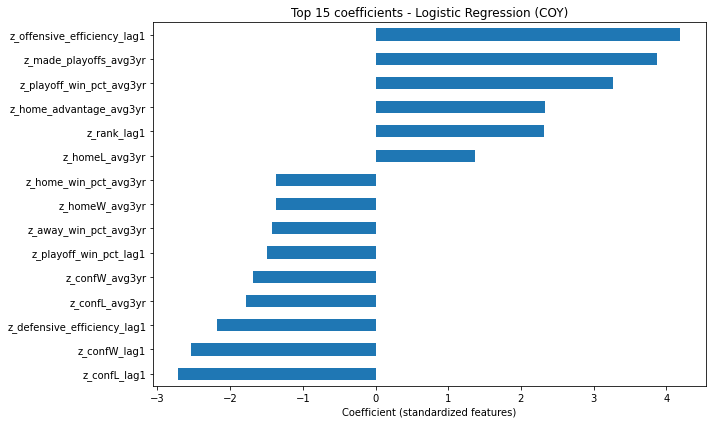


Top 15 Most Important Features (final model):
                    Feature  Importance
      z_home_win_pct_avg3yr    0.106855
               z_confL_lag1    0.084386
z_offensive_efficiency_lag1    0.081870
     z_playoff_win_pct_lag1    0.071717
    z_home_advantage_avg3yr    0.056969
       z_made_playoffs_lag1    0.056904
      z_win_percentage_lag1    0.054003
             z_stint_avg3yr    0.053997
             z_homeW_avg3yr    0.047683
               z_confW_lag1    0.046744
z_defensive_efficiency_lag1    0.045230
             z_homeL_avg3yr    0.037705
  z_conference_win_pct_lag1    0.036448
             z_confL_avg3yr    0.029135
      z_home_advantage_lag1    0.023236


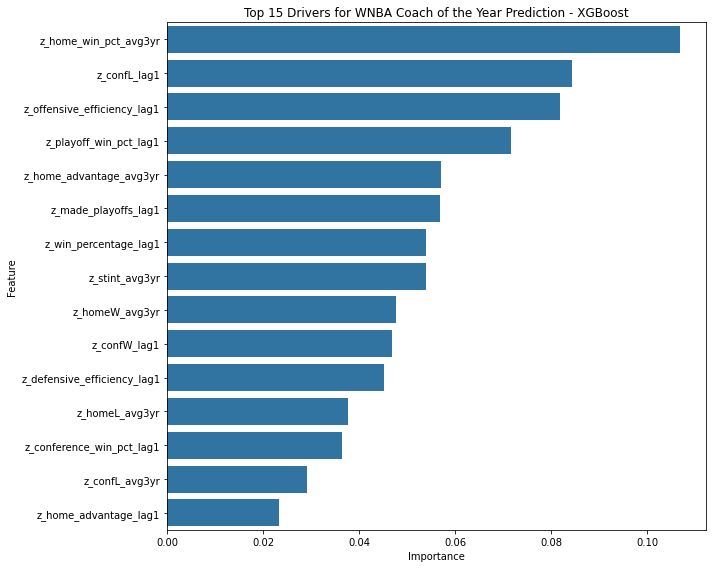

In [96]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (COY)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for WNBA Coach of the Year Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
